In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import math

## Numpy

In [2]:
img = np.array(Image.open('../../data/IPA.jpg'))

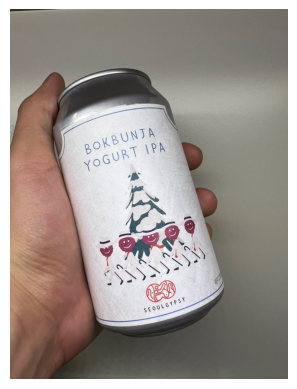

In [3]:
# 원본 이미지
plt.imshow(img)
plt.axis('off')
plt.show()

##### rot90을 이용한 회전

- np.rot90(array, k)는 배열을 시계 반대 방향으로 90°씩 k번 회전
- 내부적으로 배열 인덱스를 재배치하여 새로운 배열 생성
---
[참고1](https://numpy.org/doc/2.3/reference/generated/numpy.rot90.html)

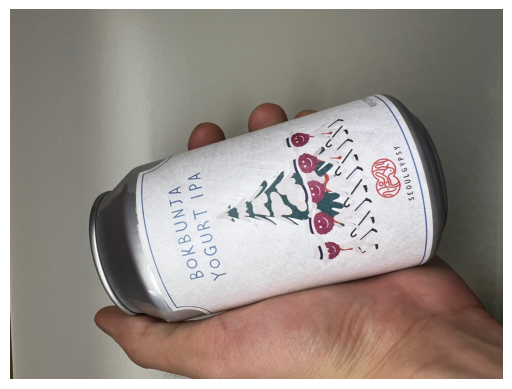

In [4]:
# 시계 반대 방향 90도 회전
rotated_90 = np.rot90(img)
plt.imshow(rotated_90)
plt.axis('off')
plt.show()

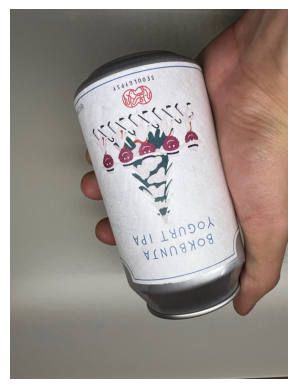

In [5]:
# 시계 반대 방향 180도 회전
rotated_180 = np.rot90(img, 2)
plt.imshow(rotated_180)
plt.axis('off')
plt.show()

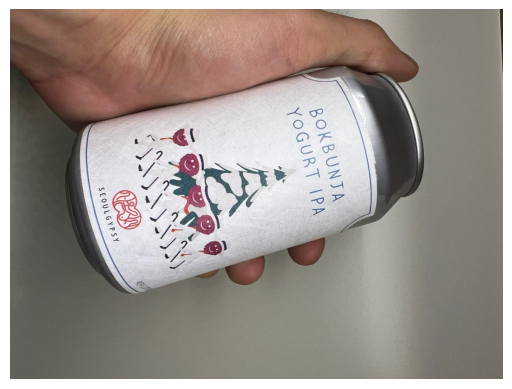

In [6]:
# 시계 반대 방향 270도 회전
rotated_270 = np.rot90(img, 3)
plt.imshow(rotated_270)
plt.axis('off')
plt.show()

#### 상하/좌우 반전

##### numpy flip
- 주어진 축을 따라 배열의 요소 순서를 뒤집음
---
[참고1](https://numpy.org/doc/2.3/reference/generated/numpy.flip.html#numpy.flip)
[참고2](https://numpy.org/doc/2.3/reference/generated/numpy.flipud.html#numpy.flipud)
[참고3](https://numpy.org/doc/2.3/reference/generated/numpy.fliplr.html#numpy.fliplr)

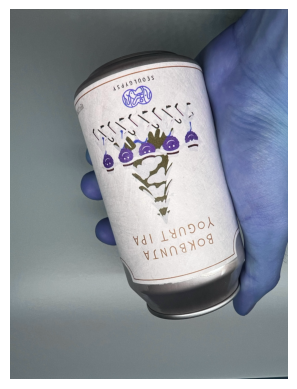

In [7]:
# 상하/좌우/색상 반전 numpy flip 활용
# f_flipped = np.flip(img,0) # 상하 반전        행
# f_flipped = np.flip(img,1) # 좌우 반전        열
# f_flipped = np.flip(img,-1) # 색상 반전       채널(RGB)
f_flipped = np.flip(img) # 상하 좌우 색상 반전
plt.imshow(f_flipped)
plt.axis('off')
plt.show()

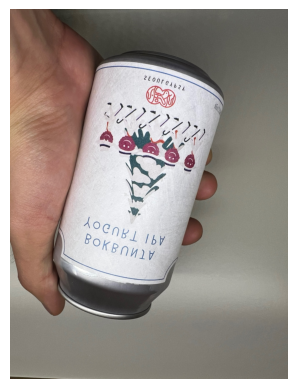

In [8]:
# 상하 반전 np.flipud(arr) = np.flip(arr, axis=0)
v_flipped = np.flipud(img)
plt.imshow(v_flipped)
plt.axis('off')
plt.show()

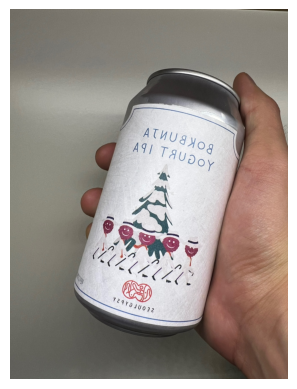

In [9]:
# 좌우 반전 np.fliplr(arr) = np.flip(arr, axis=1)
h_flipped = np.fliplr(img)
plt.imshow(h_flipped)
plt.axis('off')
plt.show()

##### slicing
- start:stop:step

---
[참조1](https://www.geeksforgeeks.org/python/python-slicing-multi-dimensional-arrays/)

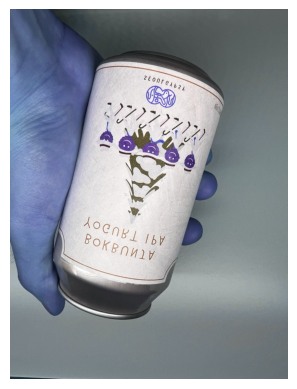

In [10]:
# 상하/좌우 반전 slicing
# s_flipped = img[::-1, :]        # 상하 반전
# s_flipped = img[:, ::-1]        # 좌우 반전
# s_flipped = img[:, :, ::-1]     # 색상 반전
# s_flipped = img[::-1, ::-1]     # 상하 좌우 반전
s_flipped = img[::-1, :, ::-1]     # 상하 색상 반전
plt.imshow(s_flipped)
plt.axis('off')
plt.show()

#### 밝기 조절 

img * x
- x가 1 이상 = 픽셀 값 증가 / x가 1 이하 = 픽셀 값 감소

numpy clip(a, a_min, a_max)
- 구간이 주어지면, 해당 구간 밖의 값은 구간 경계에 자름 (= 구간 안의 범위로 제한)
- 255보다 큰 값은 모두 255로 제한

.astype(np.unit8)
- 연산 후 float 타입을 다시 unit8 정수로 변환


---
[참조](https://numpy.org/doc/2.3/reference/generated/numpy.clip.)

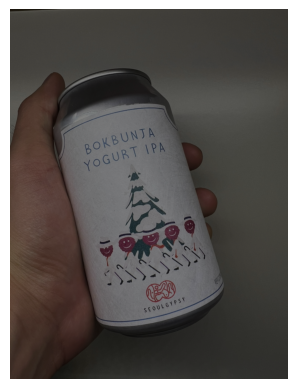

In [11]:
# bright_img = np.clip(img * 1.5, 0, 255).astype(np.uint8)    # 밝기 증가
bright_img = np.clip(img * 0.5, 0, 255).astype(np.uint8)    # 밝기 감소
plt.imshow(bright_img)
plt.axis('off')
plt.show()

#### 대비 조절

mean_val = np.mean(img)
- 전체 픽셀 평균 값

mean_val + x * (img - mean_val)
- x * (img - mean_val) = x * 평균과 원본 픽셀의 차이


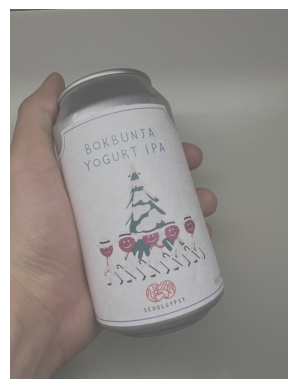

In [12]:
# 대비 증가
mean_val = np.mean(img)
# contrast = np.clip(mean_val + 2.0 * (img - mean_val), 0, 255).astype(np.uint8)  # 고대비
contrast = np.clip(mean_val + 0.5 * (img - mean_val), 0, 255).astype(np.uint8)  # 저대비
plt.imshow(contrast)
plt.axis('off')
plt.show()

#### 노이즈 / 크롭

noise = np.random.normal(평균, 표준편차, 배열의 크기)
- 평균>0 밝아짐 평균<0 어두워짐
- 표준편차 = 노이즈 정도
- img.shape = 원본 이미지 크기

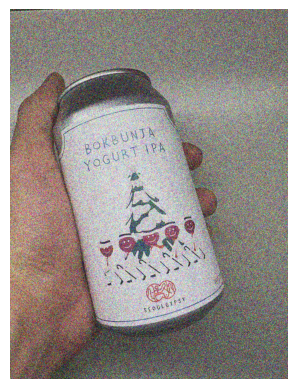

In [13]:
# 노이즈 추가
noise = np.random.normal(0, 100, img.shape)
noisy_img = np.clip(img + noise, 0, 255).astype(np.uint8)
plt.imshow(noisy_img)
plt.axis('off')
plt.show()

h, w = img.shape[:2]
- 이미지의 세로(h), 가로(w) 크기를 가져옴 (색상 제외)

start_y = (h - crop_h)

start_x = (w - crop_w)
- 전체 이미지 중앙에서 크롭 시작 좌표 계산

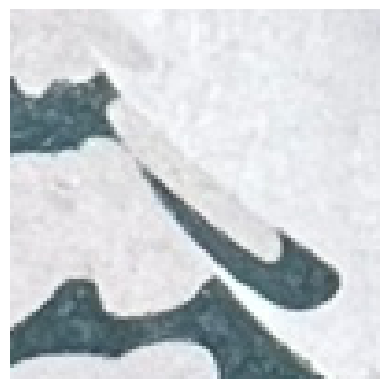

In [14]:
# 중앙 크롭
h, w = img.shape[:2]
crop_h, crop_w = 100, 100  # 크롭 크기
start_y = (h - crop_h) // 2
start_x = (w - crop_w) // 2
cropped_img = img[start_y:start_y+crop_h, start_x:start_x+crop_w]
plt.imshow(cropped_img)
plt.axis('off')
plt.show()

#### 임의 각도 회전

[참고](https://medium.com/@bosssds65/how-to-rotate-image-using-only-numpy-in-15-lines-ddc1fca93c87)

/tmp/ipykernel_33320/4045861362.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_x = pivot_point_x + int(rotate_mat[0])
/tmp/ipykernel_33320/4045861362.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_y = pivot_point_y + int(rotate_mat[1])


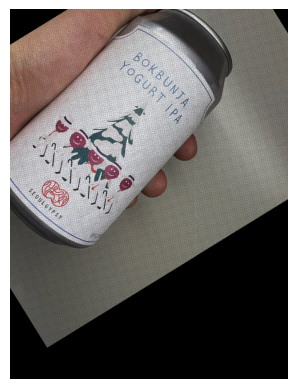

In [23]:
def rotate_image(src_img,angle_of_rotation,pivot_point,shape_img):

    #1.create rotation matrix with numpy array
    rotation_mat = np.transpose(np.array([[np.cos(angle_of_rotation),-np.sin(angle_of_rotation)],
                            [np.sin(angle_of_rotation),np.cos(angle_of_rotation)]]))
    h,w = shape_img
    
    pivot_point_x =  pivot_point[0]
    pivot_point_y = pivot_point[1]
    
    new_img = np.zeros(src_img.shape,dtype='u1') 

    for height in range(h): #h = number of row
        for width in range(w): #w = number of col
            xy_mat = np.array([[width-pivot_point_x],[height-pivot_point_y]])
            
            rotate_mat = np.dot(rotation_mat,xy_mat)

            new_x = pivot_point_x + int(rotate_mat[0])
            new_y = pivot_point_y + int(rotate_mat[1])


            if (0<=new_x<=w-1) and (0<=new_y<=h-1): 
                new_img[new_y,new_x] = src_img[height,width]

    return new_img


h,w = img.shape[:2]
center_x, center_y = h//2, w//2
rotated_45 = rotate_image(img, -45, (center_x,center_y) ,img.shape[:2])
plt.imshow(rotated_45)
plt.axis('off')
plt.show()

## PyTorch

In [ ]:
def numpy_tensor():     # pytorch tensor 변환
    return torch.from_numpy(img).permute(2, 0, 1).float() / 255.0     

def tensor_numpy(tensor):     # numpy 변환
    return tensor.permute(1, 2, 0).numpy()    


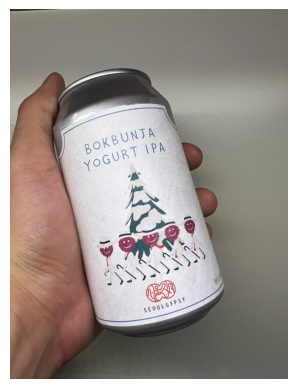

In [ ]:
tensor_img = numpy_tensor()
res_img = tensor_numpy(tensor_img)

plt.imshow(res_img)
plt.axis("off")
plt.show()

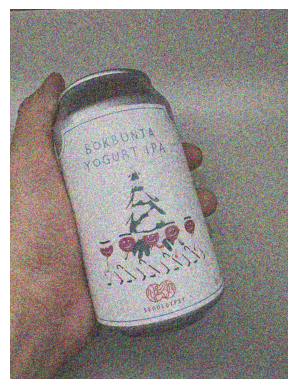

In [ ]:
tensor_img = numpy_tensor()
# 밝기
# modified_tensor_img = torch.clamp(tensor_img * 1.5, 0, 1)

# 색상 반전
# modified_tensor_img = torch.flip(tensor_img, dims=[0])

# 상하 반전
# modified_tensor_img = torch.flip(tensor_img, dims=[1])

# 좌우 반전
# modified_tensor_img = torch.flip(tensor_img, dims=[2])

# 노이즈 생성
noise = torch.randn_like(tensor_img) * 0.5
modified_tensor_img = torch.clamp(tensor + noise, 0, 1)

res_img = tensor_numpy(modified_tensor_img)

plt.imshow(res_img)
plt.axis("off")
plt.show()